# Calculate dynamic height from density profile - in the cloud

In [1]:
import numpy as np
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import pandas as pd
import gsw

## Generate density profile transects for each year

In [3]:
# open dataset
ar7w_ds = xr.open_dataset("~/efs-mount-point/mzahn/data/ar7w/igor_ar7w.nc")

In [5]:
ar7w_ds

<xarray.Dataset> Size: 113MB
Dimensions:       (time: 3072, pressure: 763)
Coordinates:
    station       (time) int64 25kB ...
  * pressure      (pressure) uint16 2kB 5 10 15 20 25 ... 3800 3805 3815 3820
  * time          (time) datetime64[ns] 25kB 1990-07-05T10:38:42.580644930 .....
    latitude      (time) float64 25kB ...
    longitude     (time) float64 25kB ...
    distance      (time) float64 25kB ...
    bottom_depth  (time) float64 25kB ...
Data variables:
    salinity      (time, pressure) float64 19MB ...
    temperature   (time, pressure) float64 19MB ...
    sigma         (time, pressure) float64 19MB ...
    sigma0        (time, pressure) float64 19MB ...
    sigma1        (time, pressure) float64 19MB ...
    sigma2        (time, pressure) float64 19MB ...
Attributes:
    source:         Labrador Sea AR7W hydrography
    original_file:  00l3_ 2000d41 8 days.mat


  <br>1990: 119 casts | dist 30–895 km | 88 grid nodes filled
  <br>1991: 25 casts | dist 149–905 km | 77 grid nodes filled
  <br>1992: 104 casts | dist 149–537 km | 40 grid nodes filled
  <br>1993: 86 casts | dist 30–865 km | 85 grid nodes filled
  <br>1994: 119 casts | dist 179–895 km | 73 grid nodes filled
  <br>1995: 61 casts | dist 20–895 km | 89 grid nodes filled
  <br>1996: 158 casts | dist 10–895 km | 90 grid nodes filled
  <br>1997: 131 casts | dist 10–885 km | 89 grid nodes filled
  <br>1998: 304 casts | dist 10–786 km | 79 grid nodes filled
  <br>1999: 108 casts | dist 10–885 km | 89 grid nodes filled
  <br>2000: 59 casts | dist 179–855 km | 69 grid nodes filled
  <br>2001: 71 casts | dist 30–895 km | 88 grid nodes filled
  <br>2002: 90 casts | dist 10–895 km | 90 grid nodes filled
  <br>2003: 80 casts | dist 10–895 km | 90 grid nodes filled
  <br>2004: 51 casts | dist 80–895 km | 83 grid nodes filled
  <br>2005: 138 casts | dist 10–895 km | 90 grid nodes filled
  <br>2006: 74 casts | dist 10–895 km | 90 grid nodes filled
  <br>2007: 33 casts | dist 99–885 km | 80 grid nodes filled
  <br>2008: 66 casts | dist 10–865 km | 87 grid nodes filled
  <br>2009: 31 casts | dist 189–895 km | 72 grid nodes filled
  <br>2010: 36 casts | dist 10–895 km | 90 grid nodes filled
  <br>2011: 82 casts | dist 0–895 km | 91 grid nodes filled
  <br>2012: 31 casts | dist 149–875 km | 74 grid nodes filled
  <br>2013: 37 casts | dist 179–895 km | 73 grid nodes filled
  <br>2014: 98 casts | dist 60–895 km | 85 grid nodes filled
  <br>2015: 38 casts | dist 189–895 km | 72 grid nodes filled
  <br>2016: 47 casts | dist 149–905 km | 77 grid nodes filled
  <br>2018: 44 casts | dist 169–905 km | 75 grid nodes filled
  <br>2019: 49 casts | dist 0–905 km | 92 grid nodes filled
  <br>2020: 52 casts | dist 10–905 km | 91 grid nodes filled
  <br>2022: 96 casts | dist 40–905 km | 88 grid nodes filled
  <br>2023: 58 casts | dist 30–905 km | 89 grid nodes filled
  <br>2024: 108 casts | dist 10–875 km | 88 grid nodes filled
  <br>2025: 98 casts | dist 10–845 km | 85 grid nodes filled

## Plot

In [4]:
# ── AR7W single-year density transect ────────────────────────────────────────
# Run this cell; an ipywidgets dropdown lets you pick the year interactively.
# Requirements: xarray numpy matplotlib cmocean ipywidgets
# ─────────────────────────────────────────────────────────────────────────────

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import cmocean
import ipywidgets as widgets
from IPython.display import display

In [16]:
IN_FILE  = "~/efs-mount-point/mzahn/data/ar7w/ar7w_density_transects.nc"
PLOT_VAR = "sigma0"          # swap to "temperature", "salinity", etc.
P_MAX    = 3500              # dbar — clip pressure axis here
CMAP     = cmocean.cm.dense

# ── Load once ─────────────────────────────────────────────────────────────────
ds           = xr.open_dataset(IN_FILE)
years        = ds["year"].values.tolist()
dist_km      = ds["distance_km"].values
pressure     = ds["pressure"].values
bottom_depth = ds["bottom_depth"].values
p_mask       = pressure <= P_MAX
pressure     = pressure[p_mask]
data_all     = ds[PLOT_VAR].values[:, :, p_mask]   # (year, dist, pressure)
ds.close()

# Global colour range so the scale stays fixed across years
vmin   = np.nanpercentile(data_all, 1)
vmax   = np.nanpercentile(data_all, 99)
levels = np.linspace(vmin, vmax, 21)

# ── Plot function ─────────────────────────────────────────────────────────────
def plot_transect(year):
    yi   = years.index(year)
    data = data_all[yi]          # (distance_km, pressure)

    plt.rcParams['font.size'] = 15
    
    fig, ax = plt.subplots(figsize=(13, 5), facecolor="#111111")
    ax.set_facecolor("#0a0a0a")

    # Filled density contours
    cf = ax.contourf(dist_km, pressure, data.T,
                     levels=levels, cmap=CMAP,
                     vmin=vmin, vmax=vmax, extend="both", zorder=2)

    # Thin contour lines
    ax.contour(dist_km, pressure, data.T,
               levels=levels[::2], colors="white",
               linewidths=0.4, alpha=0.4, zorder=3)

    # Bathymetry fill
    bathy = np.clip(bottom_depth, 0, P_MAX)
    x = np.concatenate([[dist_km[0]], dist_km, [dist_km[-1]]])
    y = np.concatenate([[P_MAX],      bathy,   [P_MAX]])
    ax.fill(x, y, color="#3a3a3a", zorder=5)

    # Axes formatting
    ax.set_ylim(P_MAX, 0)
    ax.set_xlim(dist_km[0], dist_km[-1])
    ax.yaxis.set_major_locator(ticker.MultipleLocator(500))
    ax.xaxis.set_major_locator(ticker.MultipleLocator(100))
    ax.tick_params(colors="white", labelsize=12)
    for spine in ax.spines.values():
        spine.set_edgecolor("#444444")

    ax.set_xlabel("Distance along AR7W transect (km)", color="white", fontsize=10)
    ax.set_ylabel("Pressure (dbar)",                   color="white", fontsize=10)
    ax.set_title(f"AR7W Labrador Sea — {year}  |  In Situ Density",
                 color="white", fontsize=15, fontweight="bold", pad=10)

    cbar = fig.colorbar(cf, ax=ax, pad=0.01, extend="both")
    cbar.set_label(rf"$\sigma_0$  (kg m$^{{-3}}$)", color="white", fontsize=9)
    cbar.ax.yaxis.set_tick_params(color="white", labelsize=8)
    plt.setp(cbar.ax.yaxis.get_ticklabels(), color="white")
    cbar.outline.set_edgecolor("#444444")

    plt.tight_layout()
    plt.show()

In [18]:
import ipywidgets as widgets
display(widgets.Dropdown(options=["a", "b", "c"]))

Dropdown(options=('a', 'b', 'c'), value='a')

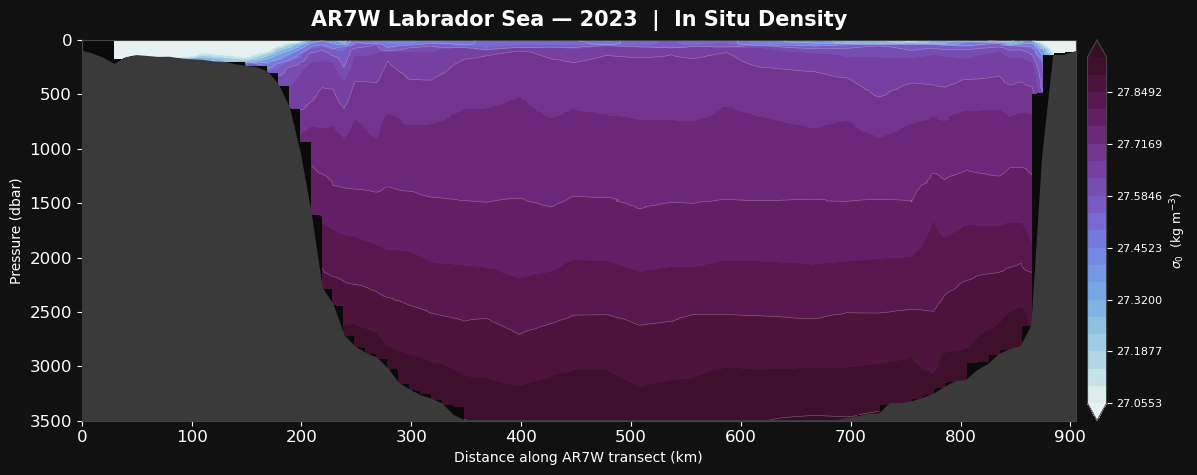

interactive(children=(Dropdown(description='Year:', index=31, layout=Layout(width='200px'), options=(1990, 199…

In [19]:
# ── Widget ────────────────────────────────────────────────────────────────────
year_widget = widgets.Dropdown(
    options=years,
    value=2023,
    description="Year:",
    style={"description_width": "initial"},
    layout=widgets.Layout(width="200px"),
)

widgets.interactive(plot_transect, year=year_widget)